In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

In [3]:
df = pd.read_csv('noisy_curvefit_data.csv')

In [4]:
print("Shape:", df.shape)
rows, cols = df.shape
print("Number of rows:", rows)
print("Number of columns:", cols)
print(df.head())
print(df.tail())
print(df.columns)


Shape: (100, 6)
Number of rows: 100
Number of columns: 6
          x  y_noise_1  y_noise_2  y_noise_3  y_noise_4  y_noise_5
0 -1.000000  11.624419   8.296963  12.201067   7.811725   3.155566
1 -0.929293  10.377466   9.674440  12.198084   8.275006   7.518855
2 -0.858586  10.585100   9.251983  13.186565  12.926586   9.963630
3 -0.787879  10.913928   7.786344  12.552304  11.832379   9.625801
4 -0.717172   8.640287   8.551869   4.741432   8.790834   6.624113
           x  y_noise_1  y_noise_2  y_noise_3  y_noise_4  y_noise_5
95  5.717172  -1.411918   0.822231  -2.027132  -1.825106   2.746147
96  5.787879   0.344879  -1.718956   2.747559  -6.803779  -5.137472
97  5.858586   0.307133   0.353528   0.967976   5.461567  -0.905616
98  5.929293   0.048657   0.159961   2.482130  -0.414616  -4.334548
99  6.000000  -0.193438  -2.244792   1.930035   4.992414  -6.872850
Index(['x', 'y_noise_1', 'y_noise_2', 'y_noise_3', 'y_noise_4', 'y_noise_5'], dtype='object')


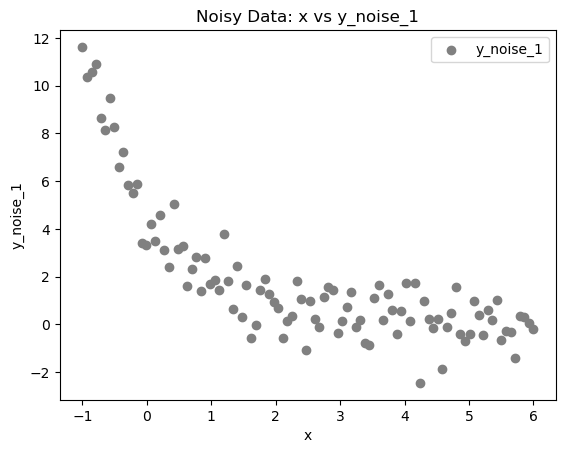

In [5]:
plt.scatter(df["x"], df["y_noise_1"], color="gray", label="y_noise_1")

plt.xlabel("x")
plt.ylabel("y_noise_1")
plt.title("Noisy Data: x vs y_noise_1")
plt.legend()

plt.show()

Fit: y = 4.71 * e^(-0.92 * x)
Reduced chi-squared: 0.79


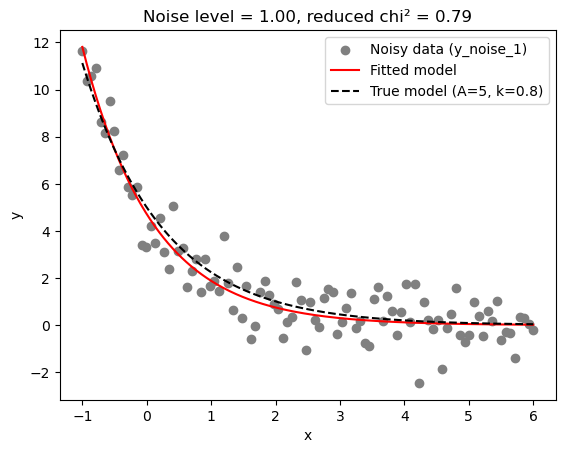

In [6]:
df = pd.read_csv("noisy_curvefit_data.csv")
x = df["x"].values
y_noise_1 = df["y_noise_1"].values
def model(x, A, k):
    return A * np.exp(-k * x)
p0 = [1, 1]
popt, pcov = curve_fit(model, x, y_noise_1, p0=p0)
A_fit, k_fit = popt
print(f"Fit: y = {A_fit:.2f} * e^(-{k_fit:.2f} * x)")
residuals = y_noise_1 - model(x, A_fit, k_fit)
chi2 = np.sum(residuals**2)
dof = len(x) - len(popt)
chi2_reduced = chi2 / dof
print(f"Reduced chi-squared: {chi2_reduced:.2f}")
x_fit = np.linspace(x.min(), x.max(), 500)
plt.scatter(x, y_noise_1, color="gray", label="Noisy data (y_noise_1)")
plt.plot(x_fit, model(x_fit, A_fit, k_fit), color="red", label="Fitted model")
plt.plot(x_fit, model(x_fit, 5, 0.8), color="black", linestyle="--", label="True model (A=5, k=0.8)")
noise_level = 1
plt.xlabel("x")
plt.ylabel("y")
plt.title(f"Noise level = {noise_level:.2f}, reduced chi² = {chi2_reduced:.2f}")
plt.legend()
plt.show()

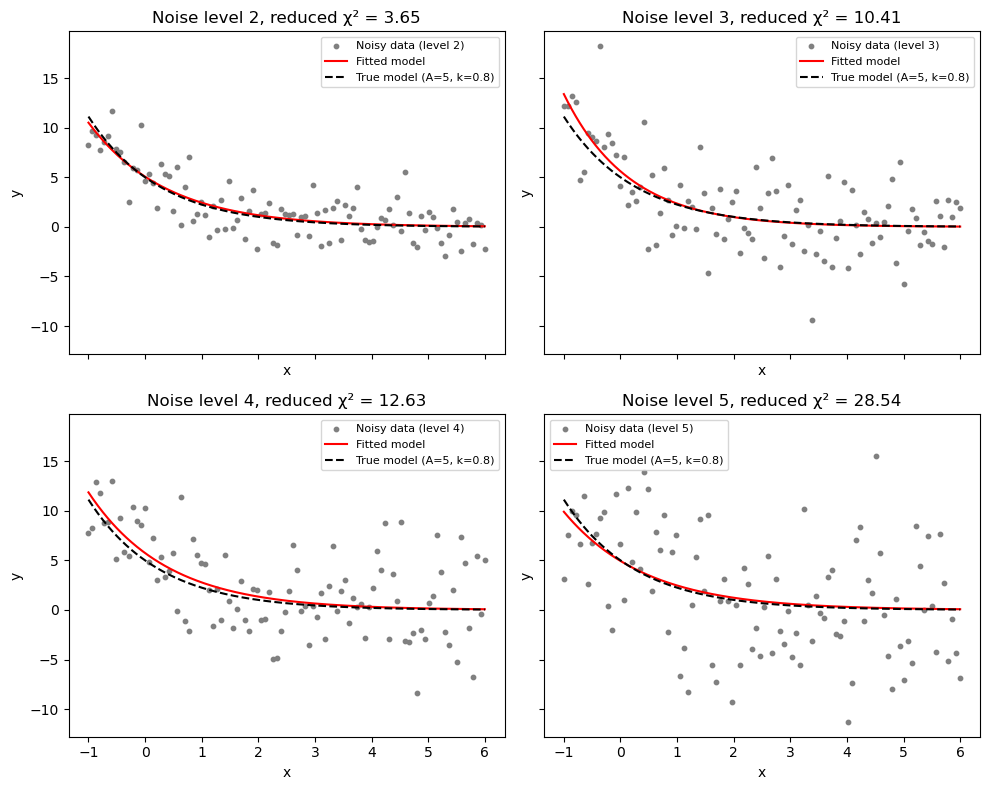

In [9]:
def fit_model(x, y):
    p0 = [1, 1]
    popt, pcov = curve_fit(model, x, y, p0=p0)
    A_fit, k_fit = popt

    residuals = y - model(x, A_fit, k_fit)
    chi2 = np.sum(residuals**2)
    dof = len(x) - len(popt)
    chi2_reduced = chi2 / dof

    return A_fit, k_fit, chi2_reduced
fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharex=True, sharey=True)
noise_cols   = ["y_noise_2", "y_noise_3", "y_noise_4", "y_noise_5"]
noise_levels = [2, 3, 4, 5]
x_fit = np.linspace(x.min(), x.max(), 500)
for ax, col, level in zip(axes.flatten(), noise_cols, noise_levels):
    y = df[col].values
    A_fit, k_fit, chi2_red = fit_model(x, y)
    ax.scatter(x, y, color="gray", s=10,label=f"Noisy data (level {level})")
    ax.plot(x_fit, model(x_fit, A_fit, k_fit),color="red", label="Fitted model")
    ax.plot(x_fit, model(x_fit, 5, 0.8),color="black", linestyle="--",label="True model (A=5, k=0.8)")
    ax.set_title(f"Noise level {level}, reduced χ² = {chi2_red:.2f}")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

# As I increase the noise level, the black dotted line is the true model, so it stays the same in every subplot.
# But The red fitted line starts close to the black line for low noise, but as the noise level increases, 
# the fit becomes less accurate and the red line can deviate more from the true model.
# With higher noise, the data scatter more around the true curve, so the fit has a harder time recovering the exact parameters.

# Reduced chi-square increases as I increase the noice level because the residual gets larger when the data are noiser. 

In [10]:
noise_cols   = ["y_noise_1", "y_noise_2", "y_noise_3", "y_noise_4", "y_noise_5"]
noise_levels = [1, 2, 3, 4, 5]
A_list   = []
k_list   = []
chi_list = []
for col in noise_cols:
    y = df[col].values
    A_fit, k_fit, chi2_red = fit_model(x, y)
    A_list.append(A_fit)
    k_list.append(k_fit)
    chi_list.append(chi2_red)
params_df = pd.DataFrame({
    "Noise level": noise_levels,
    "A fit": A_list,
    "k fit": k_list,
    "Reduced chi-squared": chi_list
})

print(params_df)
params_df.to_csv("noisy_parameters.csv", index=False)

   Noise level     A fit     k fit  Reduced chi-squared
0            1  4.714814  0.918308             0.790673
1            2  5.063889  0.730396             3.649382
2            3  5.609396  0.870372            10.410207
3            4  5.738727  0.725965            12.626832
4            5  4.943458  0.695012            28.538124
